<a href="https://colab.research.google.com/github/3Frank3/Diabetes-Risk-Prediction-Fairness-Evaluation-and-Causal-Analysis-of-Physical-Activity-Using-PSM/blob/Jolly/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01_EDA

## Load Data

In [50]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

## Create df

In [51]:
# import
from ucimlrepo import fetch_ucirepo
import pandas as pd

# load data
cdc = fetch_ucirepo(id=891)
X = cdc.data.features
y = cdc.data.targets

# combine
df = pd.concat([X, y], axis=1)

# BASIC OVERVIEW

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Info:")
df.info()

# SUMMARY STATISTICS

print("\nSummary Statistics:")
display(df.describe())

#  TARGET DISTRIBUTION

print("\nDiabetes Distribution:")
display(df['Diabetes_binary'].value_counts())
display(df['Diabetes_binary'].value_counts(normalize=True))

Shape of dataset: (253680, 22)

Columns:
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

First 5 rows:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000



Diabetes Distribution:


,count
Diabetes_binary,
0,218334
1,35346


,proportion
Diabetes_binary,
0,0.860667
1,0.139333


Set up features & code

In [44]:
import numpy as np
import matplotlib.pyplot as plt

blue = "#8FBCD4"
red = "#E26D5A"
header_blue = "#D9EAF7"

cardiometabolic_vars = [
    "BMI", "HighBP", "HighChol", "CholCheck",
    "Stroke", "HeartDiseaseorAttack"
]

lifestyle_vars = [
    "Smoker", "PhysActivity"
]

selected_vars = cardiometabolic_vars + lifestyle_vars + ["Diabetes_binary"]
eda_df = df[selected_vars].copy()

Table plotting function

In [45]:
def plot_table(table_df, title, figsize=(10, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    for j in range(len(table_df.columns)):
        table[(0, j)].set_facecolor(header_blue)
        table[(0, j)].set_text_props(weight="bold")

    plt.title(title, fontsize=16, weight="bold", pad=20)
    plt.show()

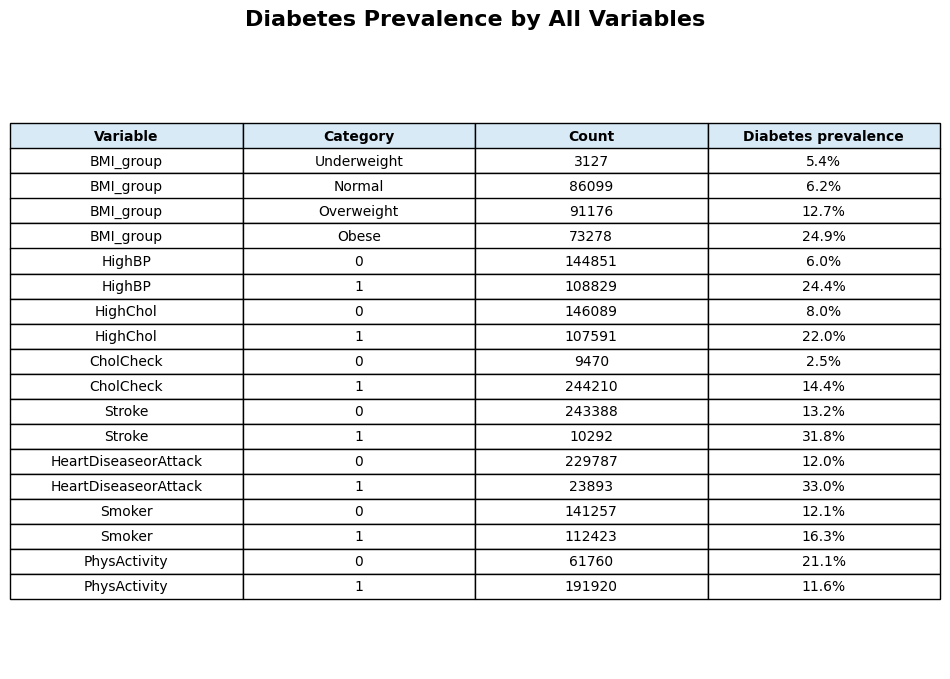

In [57]:
# Create BMI category first
df['BMI_group'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Use BMI_group instead of BMI
cardiometabolic_vars_table = [
    "BMI_group", "HighBP", "HighChol", "CholCheck",
    "Stroke", "HeartDiseaseorAttack"
]

lifestyle_vars_table = [
    "Smoker", "PhysActivity"
]

cardio_table = make_prevalence_table(df, cardiometabolic_vars_table)
lifestyle_table = make_prevalence_table(df, lifestyle_vars_table)

combined_table = pd.concat([cardio_table, lifestyle_table], axis=0)

combined_table['Diabetes prevalence'] = (
    combined_table['Diabetes prevalence'] * 100
).round(1).astype(str) + '%'

combined_table = combined_table[['Variable','Category', 'Count', 'Diabetes prevalence']]

plot_table(
    combined_table,
    "Diabetes Prevalence by All Variables",
    figsize=(12, 8)
)

In [58]:
def make_prevalence_table(df, variables):
    rows = []

    for var in variables:
        temp = df.groupby(var, observed=True)['Diabetes_binary'].agg(['count', 'mean']).reset_index()
        temp.columns = ['Category', 'Count', 'Diabetes prevalence']
        temp['Variable'] = var
        rows.append(temp)

    return pd.concat(rows, axis=0).reset_index(drop=True)

Variable Dictionary table

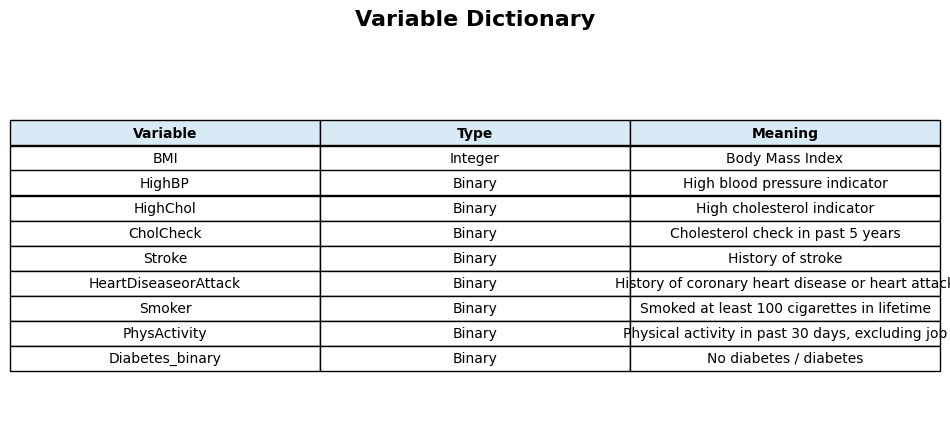

In [59]:
var_dict = pd.DataFrame({
    "Variable": [
        "BMI", "HighBP", "HighChol", "CholCheck",
        "Stroke", "HeartDiseaseorAttack",
        "Smoker", "PhysActivity", "Diabetes_binary"
    ],
    "Type": [
        "Integer", "Binary", "Binary", "Binary",
        "Binary", "Binary",
        "Binary", "Binary", "Binary"
    ],
    "Meaning": [
        "Body Mass Index",
        "High blood pressure indicator",
        "High cholesterol indicator",
        "Cholesterol check in past 5 years",
        "History of stroke",
        "History of coronary heart disease or heart attack",
        "Smoked at least 100 cigarettes in lifetime",
        "Physical activity in past 30 days, excluding job",
        "No diabetes / diabetes"
    ]
})

plot_table(var_dict, "Variable Dictionary", figsize=(12, 5))

Baseline Comparison table

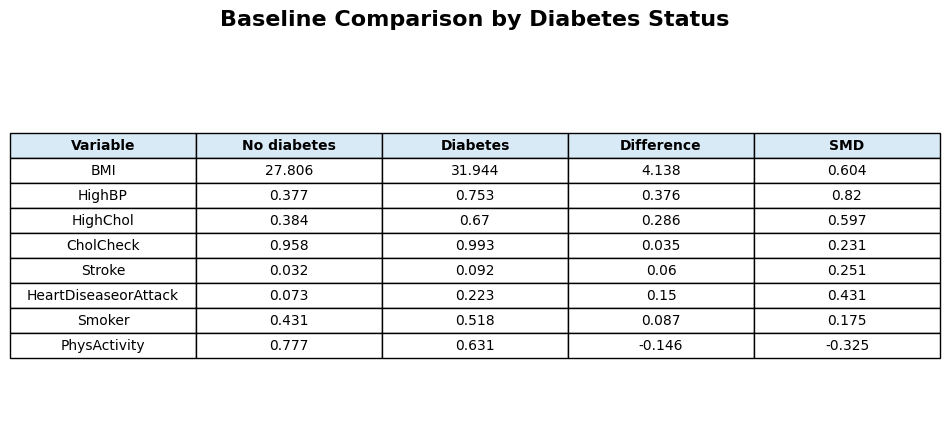

In [60]:
comparison_vars = cardiometabolic_vars + lifestyle_vars

rows = []

for var in comparison_vars:
    no_diabetes = eda_df.loc[eda_df["Diabetes_binary"] == 0, var]
    diabetes = eda_df.loc[eda_df["Diabetes_binary"] == 1, var]

    mean_0 = no_diabetes.mean()
    mean_1 = diabetes.mean()
    diff = mean_1 - mean_0

    pooled_sd = np.sqrt((no_diabetes.var() + diabetes.var()) / 2)
    smd = diff / pooled_sd if pooled_sd != 0 else np.nan

    rows.append({
        "Variable": var,
        "No diabetes": round(mean_0, 3),
        "Diabetes": round(mean_1, 3),
        "Difference": round(diff, 3),
        "SMD": round(smd, 3)
    })

baseline_table = pd.DataFrame(rows)

plot_table(baseline_table, "Baseline Comparison by Diabetes Status", figsize=(12, 5))

BMI vs Diabetes

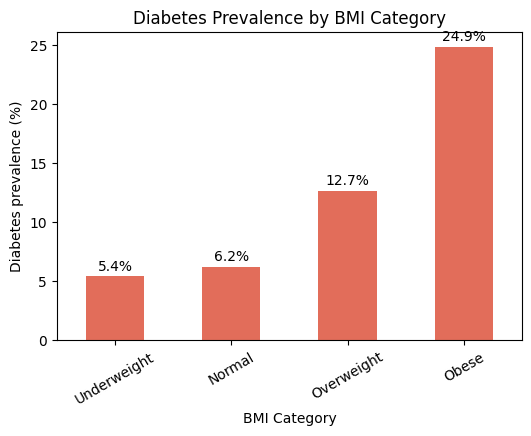

In [ ]:
df['BMI_group'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

bmi_prev = df.groupby('BMI_group', observed=True)['Diabetes_binary'].mean() * 100

ax = bmi_prev.plot(kind='bar', color=red, figsize=(6,4))
plt.title('Diabetes Prevalence by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Diabetes prevalence (%)')
plt.xticks(rotation=30)

for i, v in enumerate(bmi_prev):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

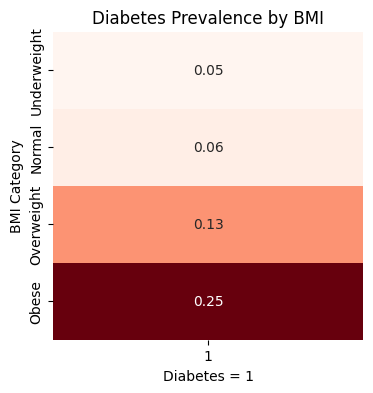

In [61]:
ct = pd.crosstab(df['BMI_group'], df['Diabetes_binary'], normalize='index')

# only keep diabetes = 1
ct = ct[[1]]

plt.figure(figsize=(4,4))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar=False
)

plt.title("Diabetes Prevalence by BMI")
plt.xlabel("Diabetes = 1")
plt.ylabel("BMI Category")

plt.show()

High bp vs Diabetes


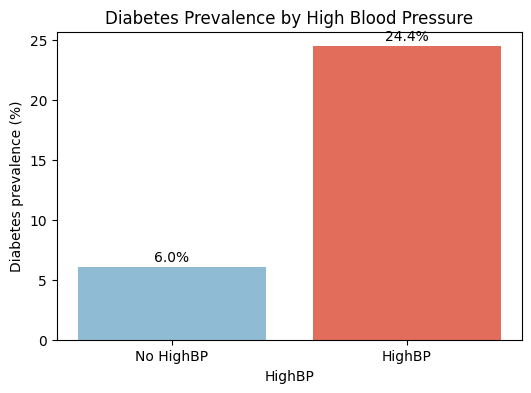

In [62]:
highbp_prev = eda_df.groupby('HighBP')['Diabetes_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    ['No HighBP', 'HighBP'],
    highbp_prev.values,
    color=["#8FBCD4", "#E26D5A"]  # blue = no, red = yes
)

ax.set_title('Diabetes Prevalence by High Blood Pressure')
ax.set_xlabel('HighBP')
ax.set_ylabel('Diabetes prevalence (%)')

# show values
for bar, value in zip(bars, highbp_prev.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.1f}%",
        ha='center'
    )

plt.show()

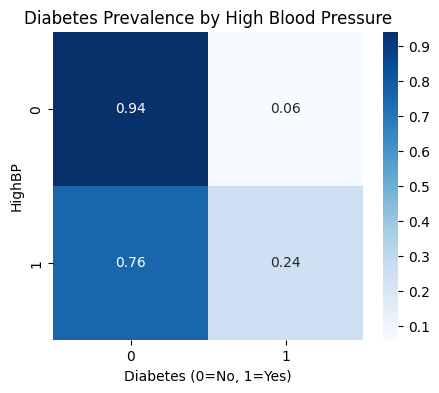

In [63]:
ct_bp = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index')

plt.figure(figsize=(5,4))

sns.heatmap(
    ct_bp,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title('Diabetes Prevalence by High Blood Pressure')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('HighBP')

plt.show()

HighChol vs Diabetes


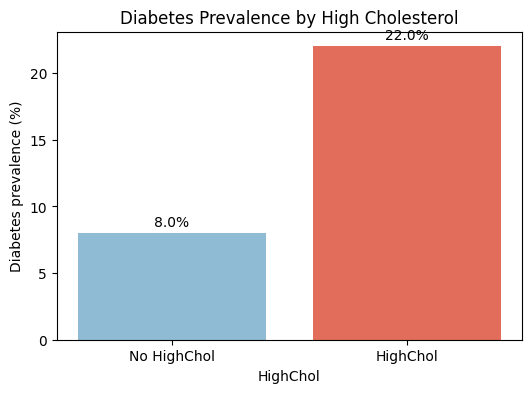

In [64]:
highchol_prev = eda_df.groupby('HighChol')['Diabetes_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    ['No HighChol', 'HighChol'],
    highchol_prev.values,
    color=["#8FBCD4", "#E26D5A"]
)

ax.set_title('Diabetes Prevalence by High Cholesterol')
ax.set_xlabel('HighChol')
ax.set_ylabel('Diabetes prevalence (%)')

# show values
for bar, value in zip(bars, highchol_prev.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.1f}%",
        ha='center'
    )

plt.show()

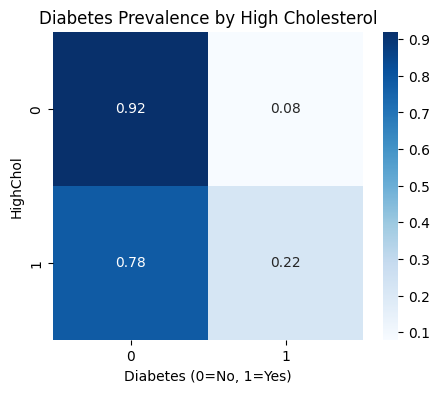

In [15]:
ct_chol = pd.crosstab(df['HighChol'], df['Diabetes_binary'], normalize='index')

plt.figure(figsize=(5,4))

sns.heatmap(
    ct_chol,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title('Diabetes Prevalence by High Cholesterol')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('HighChol')

plt.show()

CholCheck

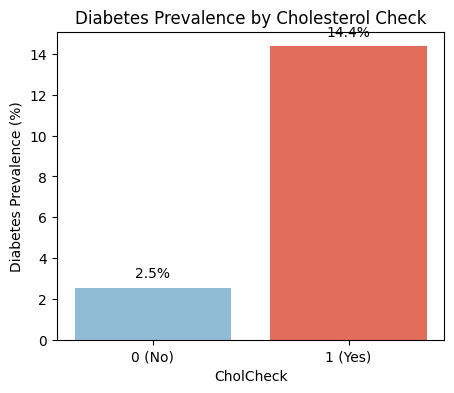

In [43]:
ct = pd.crosstab(df['CholCheck'], df['Diabetes_binary'], normalize='index')

chol_prev = ct[1] * 100

plt.figure(figsize=(5,4))

bars = plt.bar([0,1], chol_prev.values, color=['#8FBCD4', '#E26D5A'])

# add percentage labels
for i, v in enumerate(chol_prev.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.xticks([0,1], ['0 (No)', '1 (Yes)'])
plt.xlabel('CholCheck')
plt.ylabel('Diabetes Prevalence (%)')
plt.title('Diabetes Prevalence by Cholesterol Check')

plt.show()

HeartDiseaseorAttack

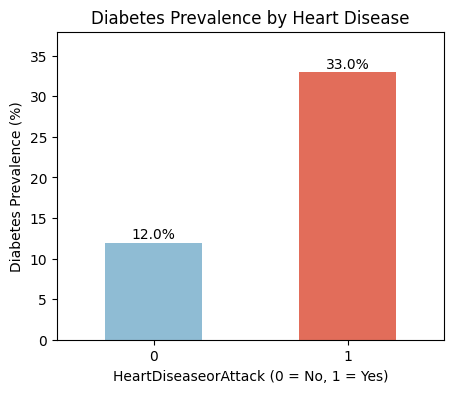

In [16]:
ct_hd = pd.crosstab(df['HeartDiseaseorAttack'], df['Diabetes_binary'], normalize='index')

ct_hd_pct = ct_hd[1] * 100

plt.figure(figsize=(5,4))

bars = ct_hd_pct.plot(kind='bar', color=['#8FBCD4', '#E26D5A'])

# labels
for i, v in enumerate(ct_hd_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.title('Diabetes Prevalence by Heart Disease')
plt.xlabel('HeartDiseaseorAttack (0 = No, 1 = Yes)')
plt.ylabel('Diabetes Prevalence (%)')

plt.ylim(0, max(ct_hd_pct) + 5)
plt.xticks(rotation=0)


plt.show()

Stroke

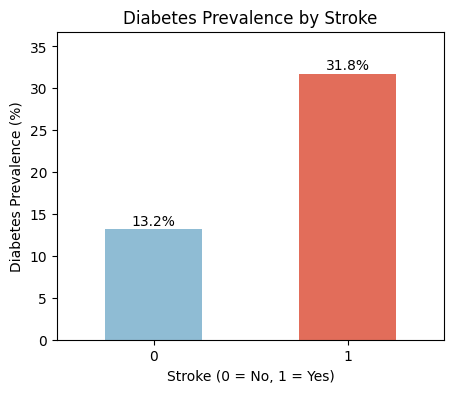

In [65]:
ct_stroke = pd.crosstab(df['Stroke'], df['Diabetes_binary'], normalize='index')
ct_stroke_pct = ct_stroke[1] * 100

plt.figure(figsize=(5,4))

ct_stroke_pct.plot(kind='bar', color=['#8FBCD4', '#E26D5A'])

# labels
for i, v in enumerate(ct_stroke_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Diabetes Prevalence by Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Diabetes Prevalence (%)')

plt.ylim(0, max(ct_stroke_pct) + 5)
plt.xticks(rotation=0)


plt.show()

Smoker

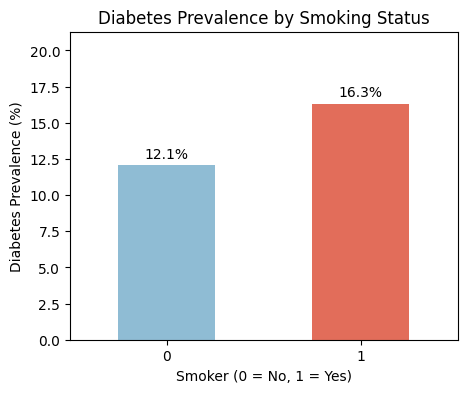

In [18]:
ct_smoker = pd.crosstab(df['Smoker'], df['Diabetes_binary'], normalize='index')
ct_smoker_pct = ct_smoker[1] * 100

plt.figure(figsize=(5,4))

ct_smoker_pct.plot(kind='bar', color=['#8FBCD4', '#E26D5A'])

# labels
for i, v in enumerate(ct_smoker_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Diabetes Prevalence by Smoking Status')
plt.xlabel('Smoker (0 = No, 1 = Yes)')
plt.ylabel('Diabetes Prevalence (%)')

plt.ylim(0, max(ct_smoker_pct) + 5)
plt.xticks(rotation=0)

plt.show()

PhysActivity

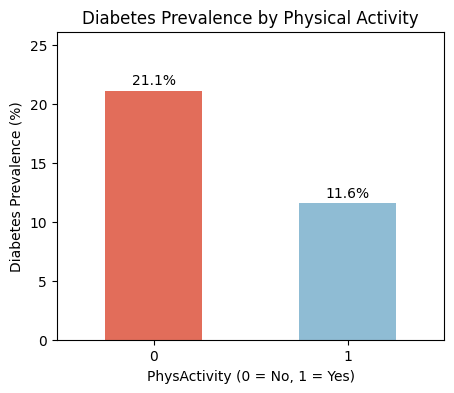

In [19]:
ct_pa = pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='index')
ct_pa_pct = ct_pa[1] * 100

plt.figure(figsize=(5,4))

ct_pa_pct.plot(kind='bar', color=['#E26D5A', '#8FBCD4'])

# labels
for i, v in enumerate(ct_pa_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Diabetes Prevalence by Physical Activity')
plt.xlabel('PhysActivity (0 = No, 1 = Yes)')
plt.ylabel('Diabetes Prevalence (%)')

plt.ylim(0, max(ct_pa_pct) + 5)
plt.xticks(rotation=0)

plt.show()

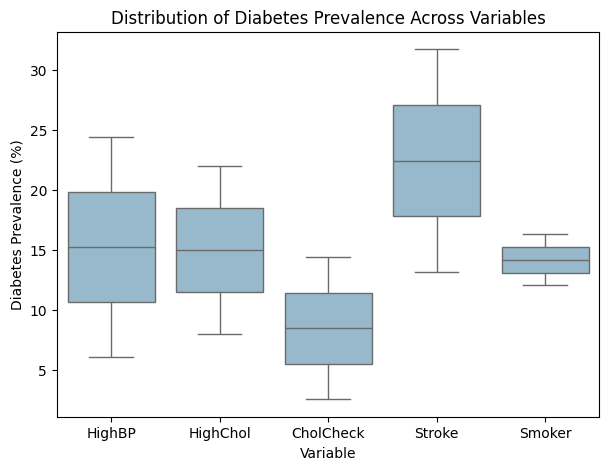

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vars_list = ['HighBP', 'HighChol', 'CholCheck', 'Stroke', 'Smoker']

rows = []

for var in vars_list:
    ct = pd.crosstab(df[var], df['Diabetes_binary'], normalize='index')

    rows.append({'Variable': var, 'Group': '0 (No)', 'Prevalence': ct.loc[0,1]*100})
    rows.append({'Variable': var, 'Group': '1 (Yes)', 'Prevalence': ct.loc[1,1]*100})

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(7,5))

sns.boxplot(
    data=plot_df,
    x='Variable',
    y='Prevalence',
    color='#8FBCD4'
)

plt.ylabel('Diabetes Prevalence (%)')
plt.title('Distribution of Diabetes Prevalence Across Variables')
plt.xticks(rotation=0)

plt.show()

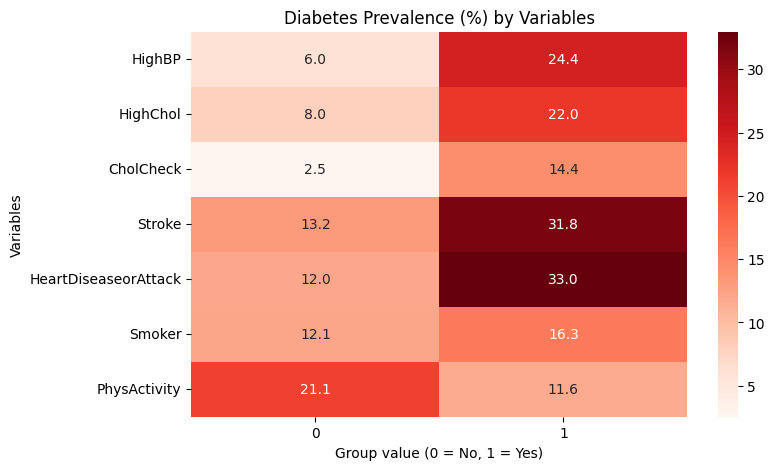

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_list = [
    'HighBP', 'HighChol', 'CholCheck',
    'Stroke', 'HeartDiseaseorAttack',
    'Smoker', 'PhysActivity'
]

# compute prevalence (only Diabetes=1)
heatmap_data = pd.DataFrame({
    var: pd.crosstab(df[var], df['Diabetes_binary'], normalize='index')[1]
    for var in vars_list
}).T

# convert to percentage
heatmap_data = heatmap_data * 100

# plot
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Diabetes Prevalence (%) by Variables")
plt.xlabel("Group value (0 = No, 1 = Yes)")
plt.ylabel("Variables")

plt.show()